In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
mu0 = 4 * np.pi * 1e-7

In [7]:
#square loop geometry, loop centre is origin
side_length = 1.0      # meters
current = 1.0          # ampere

In [8]:
def generate_square_loop(side=1.0, segments_per_side=100):
    """
    Generate discretized square loop.

    Returns:
        segment_centers : (N,3)
        dl_vectors      : (N,3)
    """

    half = side / 2

    segment_centers = []
    dl_vectors = []
    # --- Bottom side ---
    x = np.linspace(-half, half, segments_per_side, endpoint=False)
    y = -half * np.ones_like(x)

    dx = side / segments_per_side

    for xi, yi in zip(x, y):
        center = [xi + dx/2, yi, 0]
        dl = [dx, 0, 0]

        segment_centers.append(center)
        dl_vectors.append(dl)

    # --- Right side ---
    y = np.linspace(-half, half, segments_per_side, endpoint=False)
    x = half * np.ones_like(y)

    dy = side / segments_per_side

    for xi, yi in zip(x, y):
        center = [xi, yi + dy/2, 0]
        dl = [0, dy, 0]

        segment_centers.append(center)
        dl_vectors.append(dl)
    # --- Top side ---
    x = np.linspace(half, -half, segments_per_side, endpoint=False)
    y = half * np.ones_like(x)

    dx = side / segments_per_side

    for xi, yi in zip(x, y):
        center = [xi - dx/2, yi, 0]
        dl = [-dx, 0, 0]

        segment_centers.append(center)
        dl_vectors.append(dl)
    # --- Left side ---
    y = np.linspace(half, -half, segments_per_side, endpoint=False)
    x = -half * np.ones_like(y)

    dy = side / segments_per_side

    for xi, yi in zip(x, y):
        center = [xi, yi - dy/2, 0]
        dl = [0, -dy, 0]

        segment_centers.append(center)
        dl_vectors.append(dl)

    return np.array(segment_centers), np.array(dl_vectors)

In [12]:
def compute_B_field(point, segment_centers, dl_vectors, current=1.0):
    """
    Compute magnetic field at one point.

    Parameters:
        point : (3,) array

    Returns:
     _total = np.zeros(3)
    """
    B_total = np.zeros(3)
    for r0, dl in zip(segment_centers, dl_vectors):

        r_vec = point - r0
        r_mag = np.linalg.norm(r_vec)

        if r_mag < 1e-12:
            continue

        dB = (
            mu0 * current / (4 * np.pi)
            * np.cross(dl, r_vec)
            / r_mag**3
        )

        B_total += dB

    return B_total

In [13]:
#validation against analytical solution
def analytical_square_loop_center_field(side, current):
    return (2 * np.sqrt(2) * mu0 * current) / (np.pi * side)

In [14]:
#numerical validation test

segments = 200

segment_centers, dl_vectors = generate_square_loop(
    side=side_length,
    segments_per_side=segments
)

point = np.array([0, 0, 0])

B_numeric = compute_B_field(
    point,
    segment_centers,
    dl_vectors,
    current=current
)

B_analytic = analytical_square_loop_center_field(
    side_length,
    current
)

print("Numerical Bz:", B_numeric[2], "T")
print("Analytical Bz:", B_analytic, "T")

error_percent = abs(B_numeric[2] - B_analytic) / B_analytic * 100

print(f"Percent Error: {error_percent:.6f}%")

Numerical Bz: 1.1313743854194895e-06 T
Analytical Bz: 1.1313708498984761e-06 T
Percent Error: 0.000312%


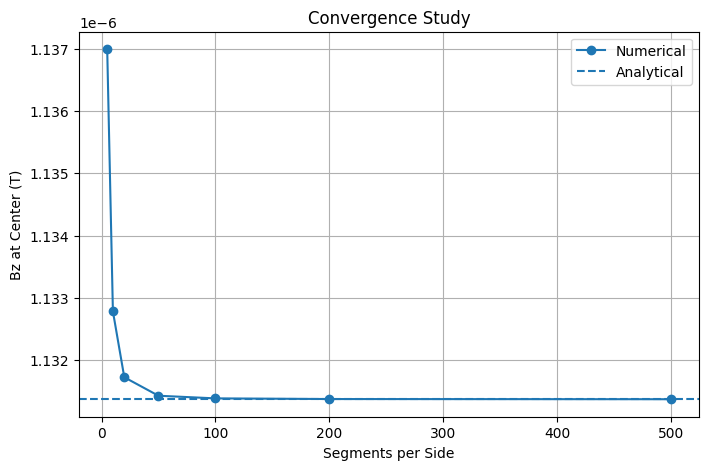

In [15]:
#convergence study
segment_list = [5, 10, 20, 50, 100, 200, 500]

results = []

for seg in segment_list:

    segment_centers, dl_vectors = generate_square_loop(
        side=side_length,
        segments_per_side=seg
    )

    B = compute_B_field(
        np.array([0,0,0]),
        segment_centers,
        dl_vectors,
        current=current
    )

    results.append(B[2])

analytic = analytical_square_loop_center_field(side_length, current)

plt.figure(figsize=(8,5))
plt.plot(segment_list, results, marker='o', label='Numerical')
plt.axhline(analytic, linestyle='--', label='Analytical')

plt.xlabel('Segments per Side')
plt.ylabel('Bz at Center (T)')
plt.title('Convergence Study')
plt.legend()
plt.grid(True)
plt.show()

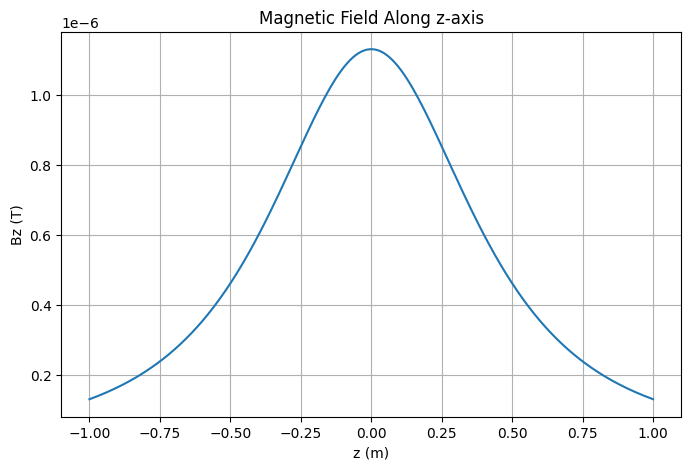

In [16]:
z_values = np.linspace(-1.0, 1.0, 200)
Bz_values = []

segment_centers, dl_vectors = generate_square_loop(
    side=side_length,
    segments_per_side=200
)

for z in z_values:

    point = np.array([0,0,z])

    B = compute_B_field(
        point,
        segment_centers,
        dl_vectors,
        current=current
    )

    Bz_values.append(B[2])
plt.figure(figsize=(8,5))
plt.plot(z_values, Bz_values)

plt.xlabel('z (m)')
plt.ylabel('Bz (T)')
plt.title('Magnetic Field Along z-axis')
plt.grid(True)
plt.show()

In [17]:
#compute magnetic field on 2D plane
N = 80

x_vals = np.linspace(-1.0, 1.0, N)
y_vals = np.linspace(-1.0, 1.0, N)

X, Y = np.meshgrid(x_vals, y_vals)

Bx = np.zeros_like(X)
By = np.zeros_like(X)
Bz = np.zeros_like(X)
Bmag = np.zeros_like(X)

In [18]:
#plane calculation

z_plane = 0.2

segment_centers, dl_vectors = generate_square_loop(
    side=side_length,
    segments_per_side=200
)

for i in tqdm(range(N)):

    for j in range(N):

        point = np.array([
            X[i,j],
            Y[i,j],
            z_plane
        ])

        B = compute_B_field(
            point,
            segment_centers,
            dl_vectors,
            current=current
        )

        Bx[i,j] = B[0]
        By[i,j] = B[1]
        Bz[i,j] = B[2]
        Bmag[i,j] = np.linalg.norm(B)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 80/80 [07:24<00:00,  5.56s/it]


In [19]:
#plotting function
def plot_field_component(field, title):

    plt.figure(figsize=(7,6))

    plt.imshow(
        field,
        extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
        origin='lower',
        aspect='equal'
    )

    plt.colorbar(label='Tesla')

    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title(title)

    plt.show()

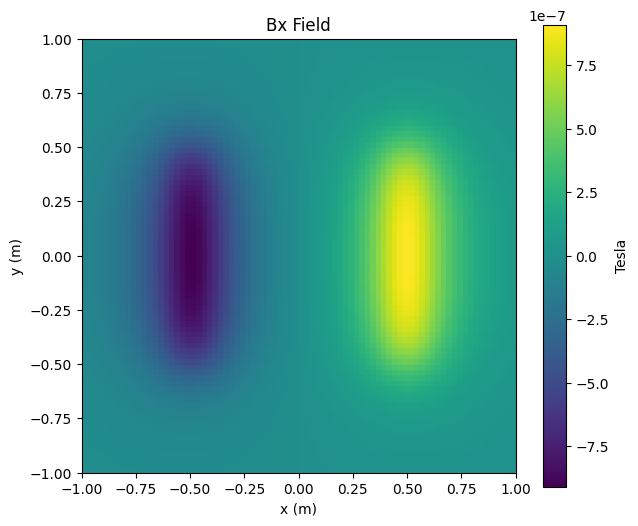

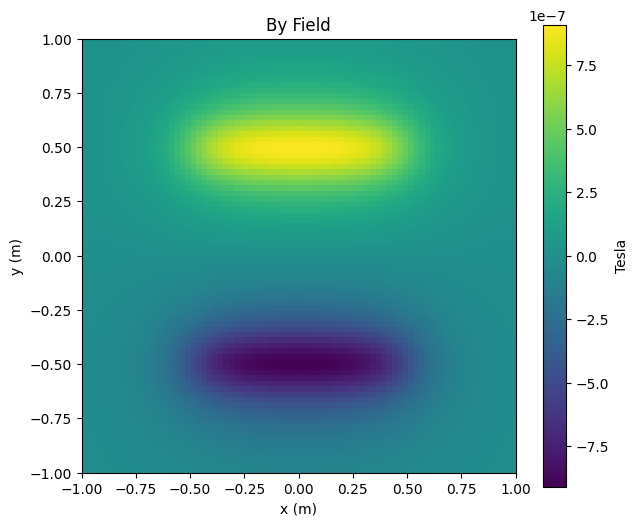

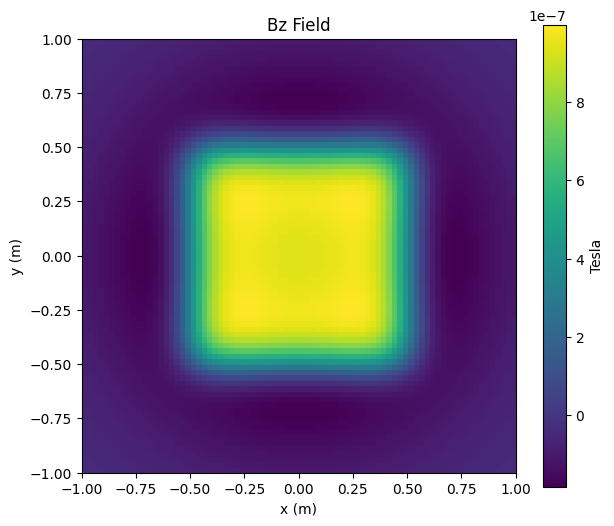

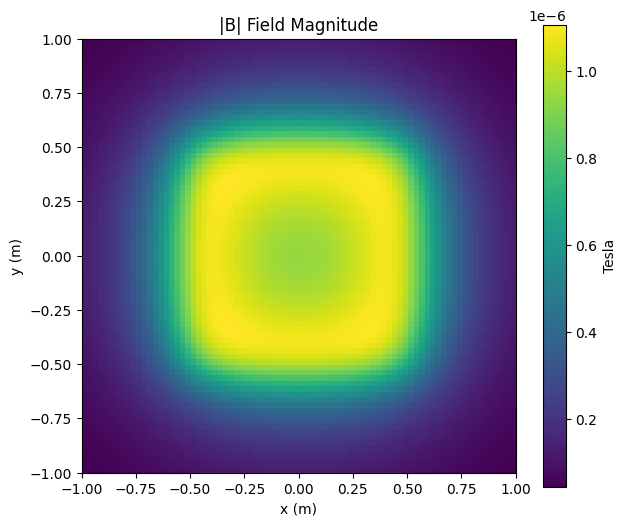

In [20]:
#plot Bx, By, Bz, |B|
plot_field_component(Bx, 'Bx Field')
plot_field_component(By, 'By Field')
plot_field_component(Bz, 'Bz Field')
plot_field_component(Bmag, '|B| Field Magnitude')

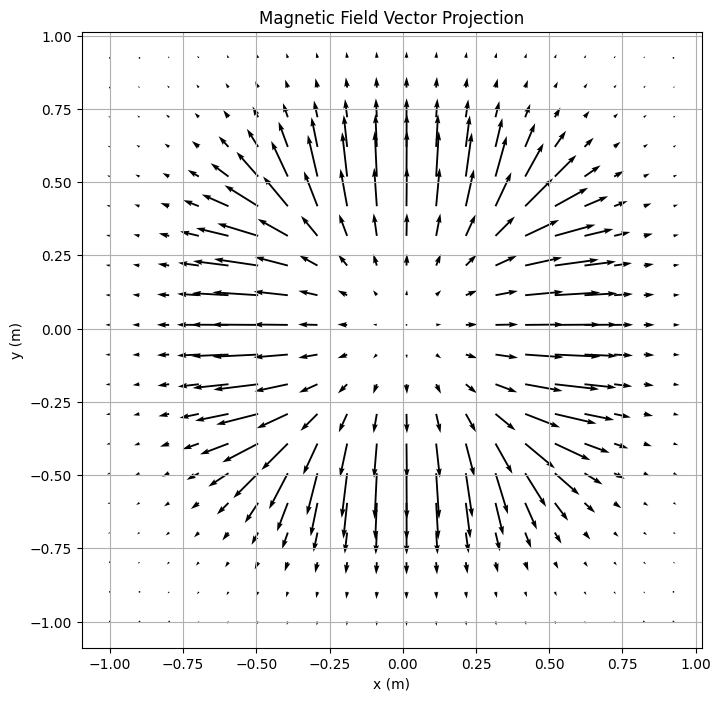

In [21]:
#vector field visualisation
skip = 4

plt.figure(figsize=(8,8))

plt.quiver(
    X[::skip,::skip],
    Y[::skip,::skip],
    Bx[::skip,::skip],
    By[::skip,::skip]
)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Magnetic Field Vector Projection')
plt.axis('equal')
plt.grid(True)
plt.show()